In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

In [10]:
file_name = "../data/delays/subway/cleaned_data/cleaned_subway_data.csv"
weather_file_name = "../data/weather/Toronto_City_Centre_2XUGG (43.63, -79.4).csv"

sub_data = pd.read_csv(file_name)

weather_data = pd.read_csv(weather_file_name)

In [11]:
sub_data["Time"] = pd.to_datetime(sub_data["Datetime"])

In [46]:
sub_data["date_only"] = pd.to_datetime(sub_data["Time"])
sub_data["date_only"] = sub_data["date_only"].dt.floor("1D")
sub_data_copy = sub_data

date_range = pd.date_range(start="2023-01-01", end="2024-12-31", freq="1D")
dummy = pd.DataFrame({'date_only': date_range})

sub_data = dummy.merge(sub_data, on='date_only', how='left')

# drop outliers (display these later)
super_delays = sub_data[sub_data["Min Delay"]>60].dropna()
super_delays = super_delays[super_delays["Min Delay"]<1000]
sub_data = sub_data[sub_data["Min Delay"]<=60] 

mean_sub_data = sub_data.groupby("date_only")[["Min Delay", "Min Gap"]].mean().reset_index()
mean_sub_data = mean_sub_data[mean_sub_data["date_only"] >= "2023-01-01"]
count_sub_data = sub_data.groupby("date_only")[["Min Delay", "Min Gap"]].count().reset_index()
count_sub_data = count_sub_data[count_sub_data["date_only"] >= "2023-01-01"]
super_means = super_delays.groupby("date_only")[["Min Delay", "Min Gap"]].mean().reset_index()

display(mean_sub_data)

display(weather_data)

,date_only,Min Delay,Min Gap
0,2023-01-01,2.906977,5.558140
1,2023-01-02,2.926829,5.219512
2,2023-01-03,2.883721,4.604651
3,2023-01-04,3.754098,5.377049
4,2023-01-05,2.088889,3.488889
...,...,...,...
726,2024-12-27,1.688312,2.584416
727,2024-12-28,1.390244,2.524390
728,2024-12-29,2.218750,3.187500
729,2024-12-30,1.613636,2.659091


,date,tavg,tmin,tmax,prcp,wdir,wspd
0,2023-01-01 0:00:00,2.5,1.5,3.3,0.3,234.0,9.1
1,2023-01-02 0:00:00,2.5,-2.0,5.5,0.0,260.0,6.8
2,2023-01-03 0:00:00,2.3,0.0,3.5,1.3,57.0,14.5
3,2023-01-04 0:00:00,3.0,2.6,3.7,25.1,66.0,17.8
4,2023-01-05 0:00:00,2.8,0.5,4.1,0.5,216.0,11.1
...,...,...,...,...,...,...,...
726,2024-12-27 0:00:00,1.2,-0.2,2.5,0.0,87.0,25.2
727,2024-12-28 0:00:00,5.4,2.4,9.2,1.0,176.0,19.0
728,2024-12-29 0:00:00,5.0,0.6,10.3,27.0,81.0,22.0
729,2024-12-30 0:00:00,4.6,2.9,9.3,2.4,238.0,36.8


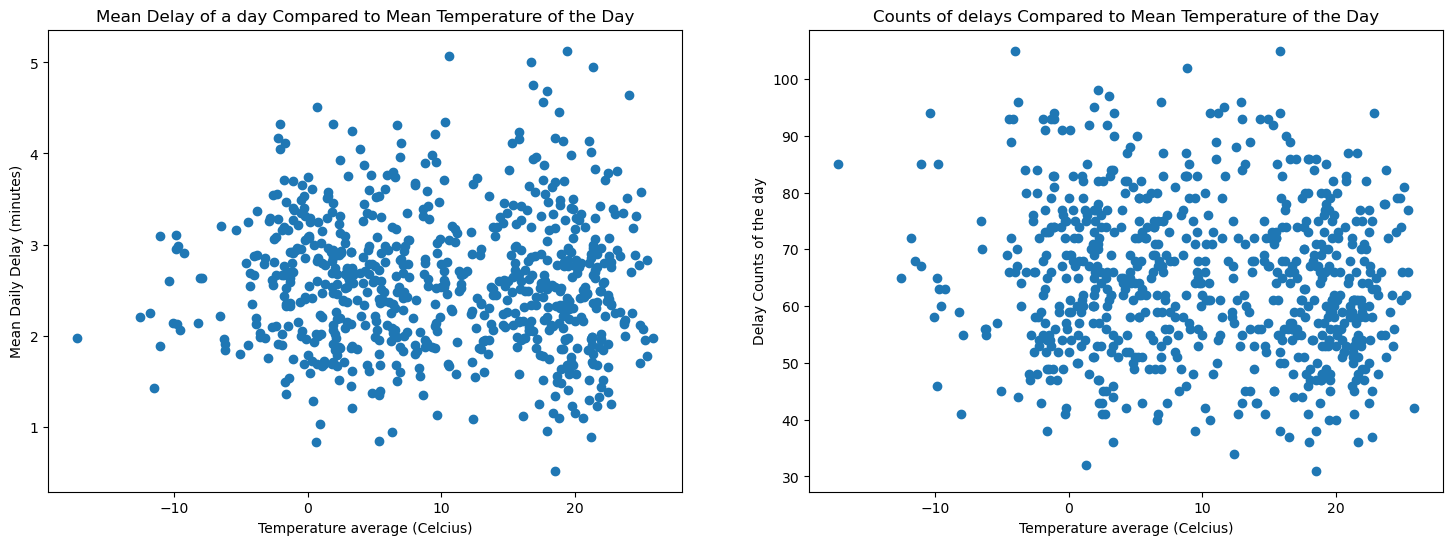

In [20]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['tavg'], mean_sub_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Mean Temperature of the Day")
axes[0].set_xlabel("Temperature average (Celcius)")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['tavg'], count_sub_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Mean Temperature of the Day")
axes[1].set_xlabel("Temperature average (Celcius)")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

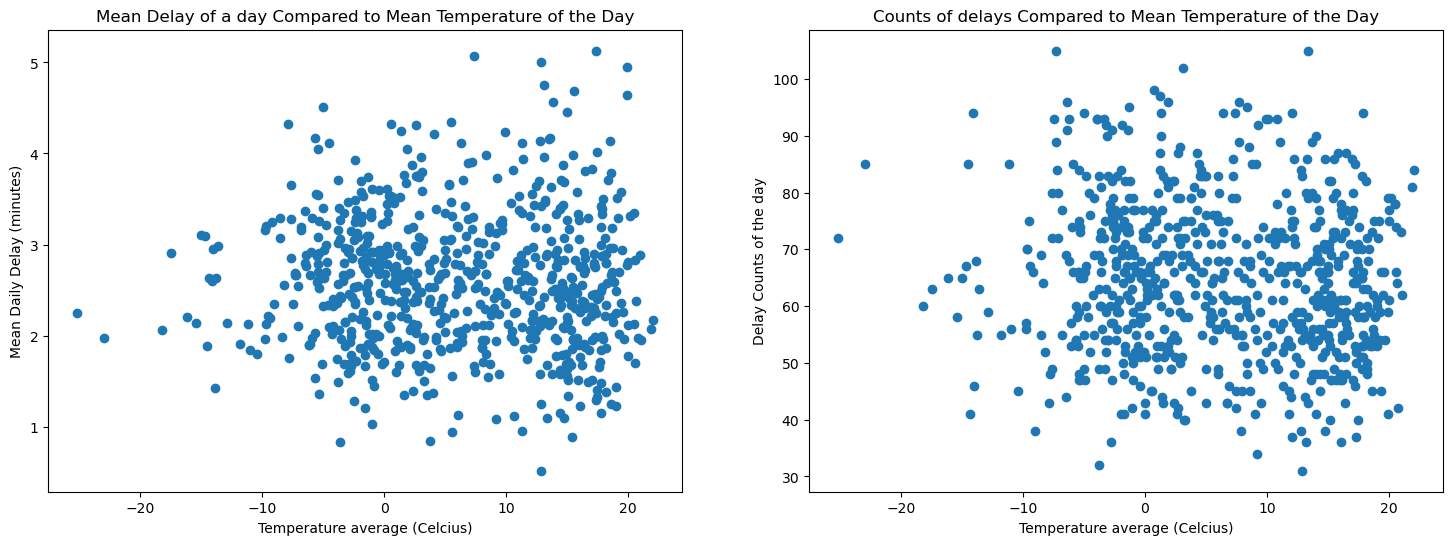

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['tmin'], mean_sub_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Min Temperature of the Day")
axes[0].set_xlabel("Temperature minimum (Celcius)")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['tmin'], count_sub_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Min Temperature of the Day")
axes[1].set_xlabel("Temperature minimum (Celcius)")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

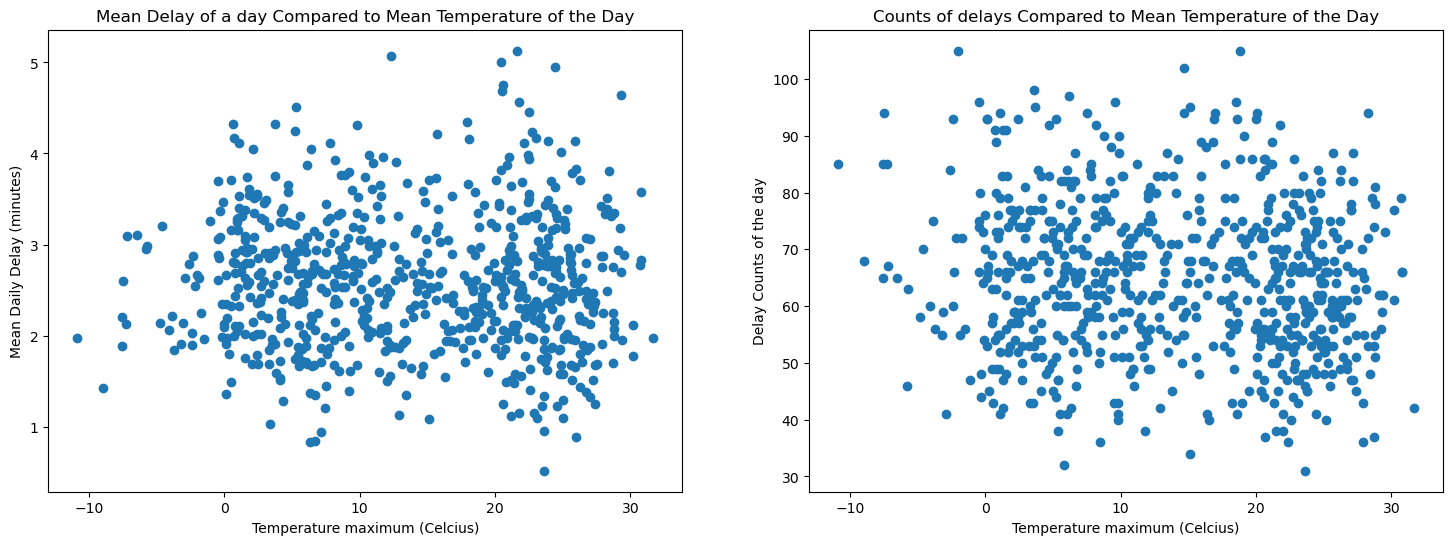

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['tmax'], mean_sub_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Max Temperature of the Day")
axes[0].set_xlabel("Temperature maximum (Celcius)")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['tmax'], count_sub_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Max Temperature of the Day")
axes[1].set_xlabel("Temperature maximum (Celcius)")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

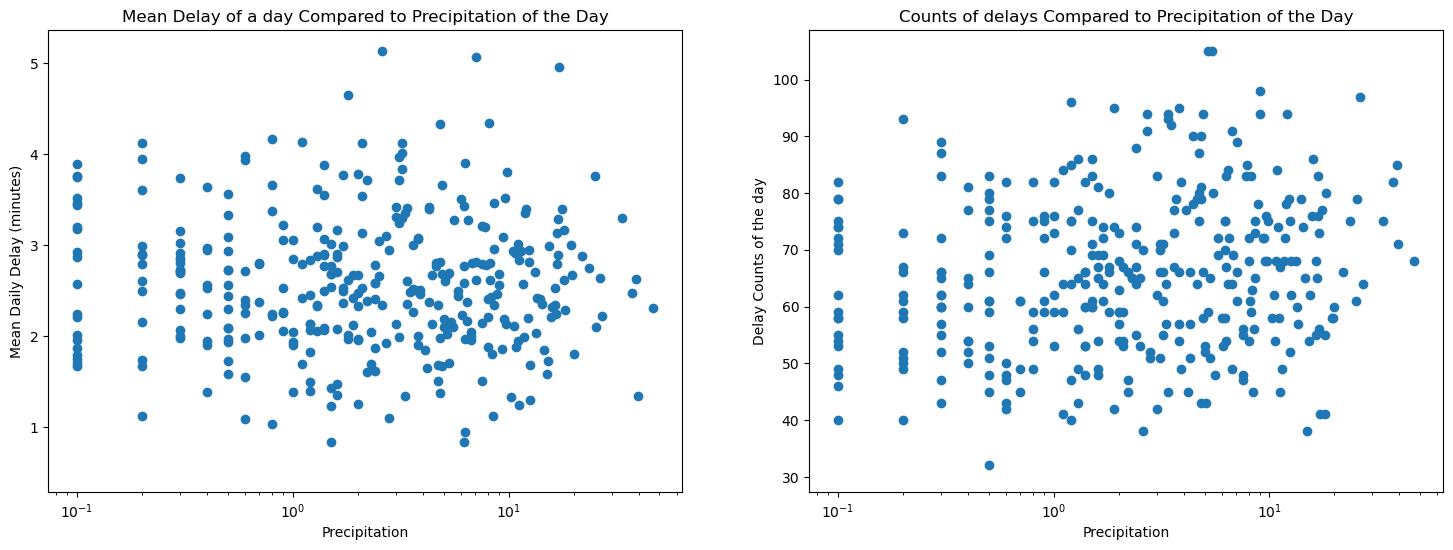

In [28]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['prcp'], mean_sub_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Precipitation of the Day")
axes[0].set_xlabel("Precipitation")
axes[0].set_ylabel("Mean Daily Delay (minutes)")
axes[0].set_xscale('log')

axes[1].scatter(weather_data['prcp'], count_sub_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Precipitation of the Day")
axes[1].set_xlabel("Precipitation")
axes[1].set_ylabel("Delay Counts of the day")
axes[1].set_xscale('log')

plt.show()

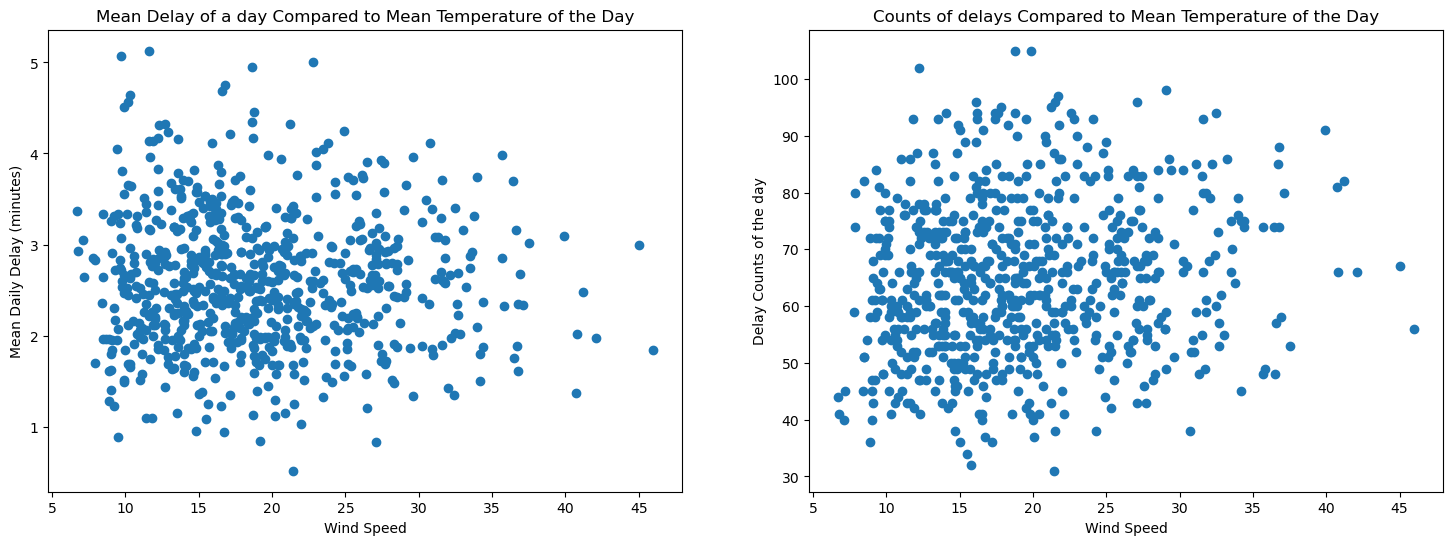

In [24]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['wspd'], mean_sub_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Mean Temperature of the Day")
axes[0].set_xlabel("Wind Speed")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['wspd'], count_sub_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Mean Temperature of the Day")
axes[1].set_xlabel("Wind Speed")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

# Multiple Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression

In [50]:
X = weather_data[weather_data.columns[1:]]
y = mean_sub_data['Min Delay']

good_rows = X.notna().all(axis=1)

X = X[good_rows]
y = y[good_rows]

model = LinearRegression().fit(X[:-100], y[:-100])

y_pred = model.predict(X[-100:])

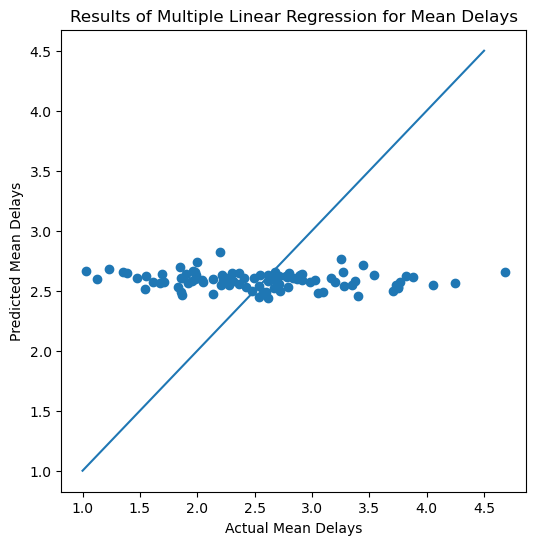

In [59]:
fig, axes = plt.subplots(1, 1, figsize = (6, 6))

axes.scatter(y[-100:], y_pred)
axes.set_title("Results of Multiple Linear Regression for Mean Delays")
axes.set_xlabel("Actual Mean Delays")
axes.set_ylabel("Predicted Mean Delays")
axes.plot(np.linspace(1, 4.5, 100),np.linspace(1, 4.5, 100))

plt.show()

In [64]:
X = weather_data[weather_data.columns[1:]]
y = count_sub_data['Min Delay']

good_rows = X.notna().all(axis=1)

X = X[good_rows]
y = y[good_rows]

model = LinearRegression().fit(X[:-100], y[:-100])

y_pred = model.predict(X[-100:])

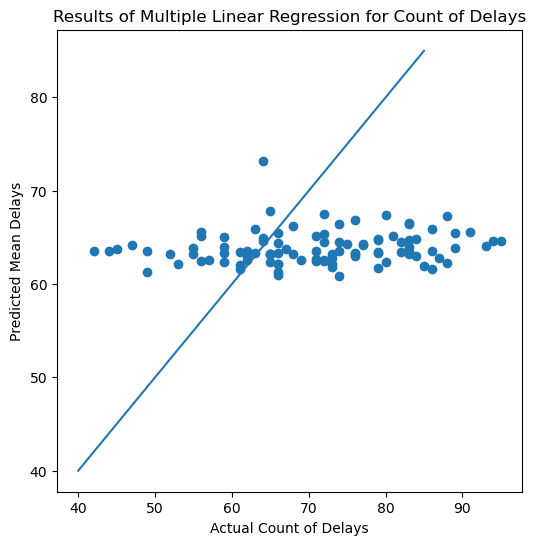

In [65]:
fig, axes = plt.subplots(1, 1, figsize = (6, 6))

axes.scatter(y[-100:], y_pred)
axes.set_title("Results of Multiple Linear Regression for Count of Delays")
axes.set_xlabel("Actual Count of Delays")
axes.set_ylabel("Predicted Mean Delays")
axes.plot(np.linspace(40, 85, 100),np.linspace(40, 85, 100))

plt.show()